In [ ]:
from google.colab import userdata
import os

GITHUB_PAT = 'your_github_key'

# Replace with your GitHub username and repository name
username = "YasBroek"
repository = "PGM-Denoising_Score_Matching"

# Clone the repository using the PAT
!git clone https://{GITHUB_PAT}@github.com/{username}/{repository}.git



Cloning into 'PGM-Denoising_Score_Matching'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 144 (delta 59), reused 116 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (144/144), 37.50 MiB | 37.65 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [ ]:
%cd /content/PGM-Denoising_Score_Matching
!pip install torchinfo

/content/PGM-Denoising_Score_Matching


In [ ]:
import os

import numpy as np

from sklearn import datasets as skdatasets

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

from matplotlib import pyplot as plt

from tqdm.notebook import tqdm

from datasets import get_dataset
from models import NCSN
from losses import NCSNLoss, GaussianPerturbation
from train import ScoreNetTrainer, Trainer
from samplers import AnnealedLangevinDynamics

from utils import get_torch_device
device = get_torch_device()
print(device)

cuda


In [ ]:
sigma0 = 1
sigmaL = 0.01
L = 10

sigmas = torch.exp(torch.linspace(np.log(sigma0), np.log(sigmaL), L)).to(device)
print(sigmas)

tensor([1.0000, 0.5995, 0.3594, 0.2154, 0.1292, 0.0774, 0.0464, 0.0278, 0.0167,
        0.0100], device='cuda:0')


In [ ]:
B = 512

train_loader, test_loader = get_dataset("mnist", batch_size=B, num_workers=2, pin_memory=False)
shape = (28, 28, 1)
model = NCSN(shape, L, filters=64)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(summary(model, [(1, *shape[::-1]), (1,)], dtypes=[torch.float, torch.long]))

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.6MB/s]


Layer (type:depth-idx)                                                           Output Shape              Param #
NCSN                                                                             [1, 1, 28, 28]            --
├─Conv2d: 1-1                                                                    [1, 64, 28, 28]           640
├─ConditionalSequential: 1-2                                                     [1, 128, 14, 14]          2,075,584
│    └─ConditionalResidualBlock: 2-1                                             [1, 64, 28, 28]           75,776
│    │    └─ConditionalInstanceNorm2dPlus: 3-1                                   [1, 64, 28, 28]           1,920
├─ConditionalSequential: 1-122                                                   --                        (recursive)
│    └─ELU: 2-2                                                                  [1, 64, 28, 28]           --
├─ConditionalSequential: 1-34                                                    --        

In [ ]:
perturbation = GaussianPerturbation()
loss_fn = NCSNLoss(perturbation, sigmas, coeff_func=lambda s: s**2)
trainer = ScoreNetTrainer(train_loader, model, device)
sampler = AnnealedLangevinDynamics(model, sigmas, device)

def sample_img(sampler, arg):
    if isinstance(arg, (list, tuple, torch.Size)):
        img = sampler.sample(shape[::-1], epsilon=2e-5).squeeze(0).permute(1, 2, 0).cpu().numpy()
    else:
        img = sampler.sample(arg, epsilon=2e-5).squeeze(0).permute(1, 2, 0).cpu().numpy()

    return img

In [ ]:
for e in range(1):
    trainer.train(loss_fn, optimizer, epochs=4, verbose=True, reset=False)
    # if e%10 == 0:
    #   img = sample_img(sampler, shape)
    #   plt.imshow(img, cmap="gray")
    #   plt.show()


  0%|          | 0/468 [00:00<?, ?batch/s]

Epoch 1 (Loss: 136.9118)


  0%|          | 0/468 [00:00<?, ?batch/s]

Epoch 2 (Loss: 58.7402)


  0%|          | 0/468 [00:00<?, ?batch/s]

Epoch 3 (Loss: 42.3796)


  0%|          | 0/468 [00:00<?, ?batch/s]

Epoch 4 (Loss: 37.1095)


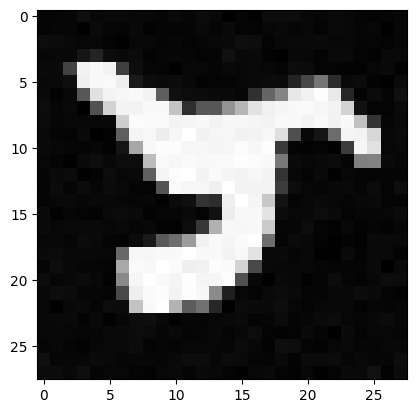

In [ ]:
img = sample_img(sampler, shape)
plt.imshow(img, cmap="gray")
plt.show()

In [ ]:
from diffusers import DiffusionPipeline, AutoencoderTiny
vae = AutoencoderTiny.from_pretrained("madebyollin/taesd", device=device)


In [ ]:
dummy_data = next(iter(train_loader))

In [ ]:
dummy_encode = vae.encode(dummy_data[0].repeat(1,3,1,1))

In [ ]:
dummy_decode = vae.decode(dummy_encode.latents)

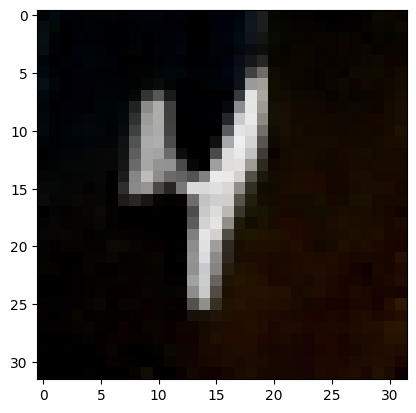

In [ ]:
plt.imshow(dummy_decode.sample[56].detach().squeeze(0).permute(1,2,0))

In [ ]:
import torch
from torch import Tensor
from torch.nn import Module, ModuleList
from torch.utils.data import DataLoader

from train import ScoreNetTrainer


class TinyVAEScoreNetTrainer(ScoreNetTrainer):
    def __init__(self, train_loader: DataLoader, score_net: Module, device: torch.device = torch.device("cpu")):
        super().__init__(train_loader, ModuleList([score_net]), device)
        self.vae = AutoencoderTiny.from_pretrained("madebyollin/taesd", torch_dtype=torch.float16, device=device)

    def _loss_batch(self, x: Tensor, loss: Module) -> Tensor:
        score_net = self.models[0]
        with torch.no_grad():
          dummy_encode = vae.encode(x)
          x = dummy_encode.latents
        return loss(x, score_net)


In [ ]:
B = 1

train_loader, test_loader = get_dataset("cifar10", batch_size=B, num_workers=2, pin_memory=False)


100%|██████████| 170M/170M [00:03<00:00, 43.7MB/s]


In [ ]:
dummy_data = next(iter(train_loader))
with torch.no_grad():
  dummy_encode = vae.encode(dummy_data[0])
  dummy_decode = vae.decode(dummy_encode.latents)

In [ ]:
shape_vae = (4, 4, 4)
L_vae = 10
model_vae = NCSN(shape_vae, L_vae, filters=64)
trainer_vae = TinyVAEScoreNetTrainer(train_loader, model_vae, 'cuda')


In [ ]:
dummy_encode.latents.shape, dummy_decode.sample[0].shape, dummy_data[0].shape

(torch.Size([1, 4, 4, 4]), torch.Size([3, 32, 32]), torch.Size([1, 3, 32, 32]))

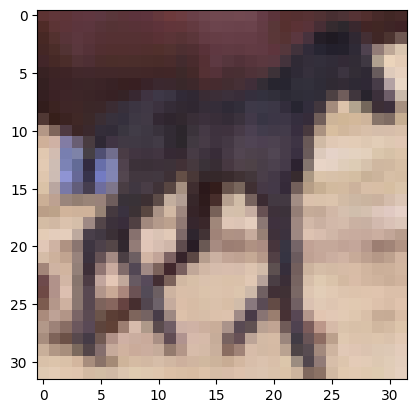

In [ ]:
# plt.imshow(dummy_decode.sample[0].detach().squeeze(0).permute(1,2,0))
plt.imshow(dummy_data[0][0].detach().squeeze(0).permute(1,2,0))

In [ ]:
B = 512

train_loader, test_loader = get_dataset("mnist", batch_size=B, num_workers=2, pin_memory=False)
shape_vae = (4, 4, 4)
L_vae = 10
model_vae = NCSN(shape_vae, L_vae, filters=64)
optimizer = torch.optim.Adam(model_vae.parameters(), lr=1e-3)

In [ ]:
for e in range(1):
    trainer.train(loss_fn, optimizer, epochs=4, verbose=True, reset=False)


  0%|          | 0/468 [00:00<?, ?batch/s]

Epoch 1 (Loss: 35.7525)


  0%|          | 0/468 [00:00<?, ?batch/s]

Epoch 2 (Loss: 35.8453)


  0%|          | 0/468 [00:00<?, ?batch/s]

Epoch 3 (Loss: 35.6407)


  0%|          | 0/468 [00:00<?, ?batch/s]

Epoch 4 (Loss: 35.8127)


In [ ]:
from samplers import AnnealedLangevinDynamics
sampler_vae = AnnealedLangevinDynamics(model_vae, sigmas, 'cuda')

In [ ]:
img = sampler_vae.sample(shape_vae)

In [ ]:
vae.to(device)

In [ ]:
with torch.no_grad():
  decoded_sample = vae.decode(img.to(device))

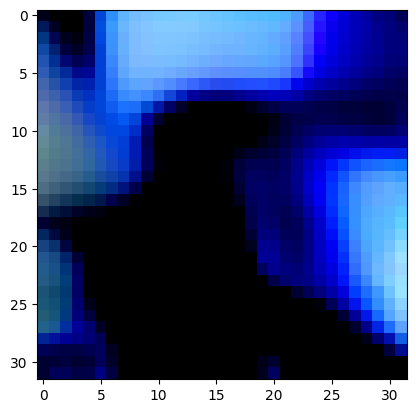

In [ ]:
plt.imshow(decoded_sample.sample[0].cpu().squeeze(0).permute(1,2,0))